# Chapter 2 — Exploratory Data Analysis

### Chapter Overview

Exploratory Data Analysis is conducted before modelling to understand
the structure and statistical properties of the freMTPL2 dataset.
The findings here directly motivate the modelling choices in Chapter 3, 
particularly the selection of Negative Binomial over Poisson regression
and Gamma vs Lognormal for severity.

| Section | Activity |
|---------|----------|
| 2.1 | Load prepared data |
| 2.2 | Claim count distribution |
| 2.3 | Claim amount distribution |
| 2.4 | Overdispersion test |
| 2.5 | Exposure distribution |
| 2.6 | Correlation heatmap |
| 2.7 | EDA summary and modelling implications |

> **Research connection:** This chapter provides empirical evidence for
> RQ1 (overdispersion in claim counts) and RQ2 (severity distribution
> shape) from Chapter 0, directly informing GLM selection in Chapter 3.

---


# ── 2.1 IMPORTS AND LOAD ─────────────────────────────────────
### 2.1 Import Libraries and Load Data

Prepared data is loaded from the compressed files saved by Chapter 1.


In [2]:
# ── Libraries ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader import load_prepared_data

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# ── Load prepared data from Chapter 1 ────────────────────────
data = load_prepared_data()

df         = data['df']
df_sev     = data['df_severity']
y_freq     = pd.concat([data['y_freq_train'], data['y_freq_test']])
y_sev      = pd.concat([data['y_sev_train'],  data['y_sev_test']])
exposure   = pd.concat([data['exposure_train'], data['exposure_test']])

print(f"\\nFull dataset     : {df.shape}")
print(f"Severity subset  : {df_sev.shape}")
print(f"Claim records    : {len(y_sev):,}")

# ── Set up plots folder ───────────────────────────────────────
def find_plots_dir():
    current = os.getcwd()
    for _ in range(4):
        candidate = os.path.join(current, 'plots')
        if os.path.exists(candidate):
            return candidate
        current = os.path.dirname(current)
    # Create it if not found
    plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'plots')
    os.makedirs(plots_dir, exist_ok=True)
    return plots_dir

PLOTS_DIR = find_plots_dir()
print(f"Plots folder     : {PLOTS_DIR}")


Loading prepared data from data/ folder...
All datasets loaded successfully.
   Full dataset     : (678013, 47)
   Severity subset  : (24944, 47)
   Freq train/test  : (542410, 44) / (135603, 44)
   Sev  train/test  : (19955, 44) / (4989, 44)
\nFull dataset     : (678013, 47)
Severity subset  : (24944, 47)
Claim records    : 24,944
Plots folder     : C:\Users\Administrator\Desktop\insurance-claims-modelling\plots


# ── 2.2 CLAIM COUNT DISTRIBUTION ─────────────────────────────
### 2.2 Claim Count Distribution

The distribution of ClaimNb (number of claims per policy) is examined
to understand the frequency structure of the data. In motor insurance,
the vast majority of policyholders file zero claims in any given year,
making the distribution highly zero inflated and right skewed.

Understanding this distribution is essential for selecting the correct
regression family in Chapter 3. A Poisson distribution assumes the
variance equals the mean. If this assumption is violated (overdispersion),
Negative Binomial regression is required.


In [4]:
# ── Claim count distribution ──────────────────────────────────
claim_counts = df['ClaimNb'].value_counts().sort_index()

print("ClaimNb Distribution:")
print(f"{'Claims':>8} {'Policies':>12} {'Percentage':>12}")
print("-" * 35)
for val, count in claim_counts.items():
    pct = count / len(df) * 100
    print(f"{val:>8} {count:>12,} {pct:>11.2f}%")

print(f"\\nTotal policies : {len(df):,}")
print(f"Mean ClaimNb   : {df['ClaimNb'].mean():.6f}")
print(f"Variance       : {df['ClaimNb'].var():.6f}")


ClaimNb Distribution:
  Claims     Policies   Percentage
-----------------------------------
       0      643,953       94.98%
       1       32,178        4.75%
       2        1,784        0.26%
       3           82        0.01%
       4            7        0.00%
       5            2        0.00%
       6            1        0.00%
       8            1        0.00%
       9            1        0.00%
      11            3        0.00%
      16            1        0.00%
\nTotal policies : 678,013
Mean ClaimNb   : 0.053247
Variance       : 0.057656


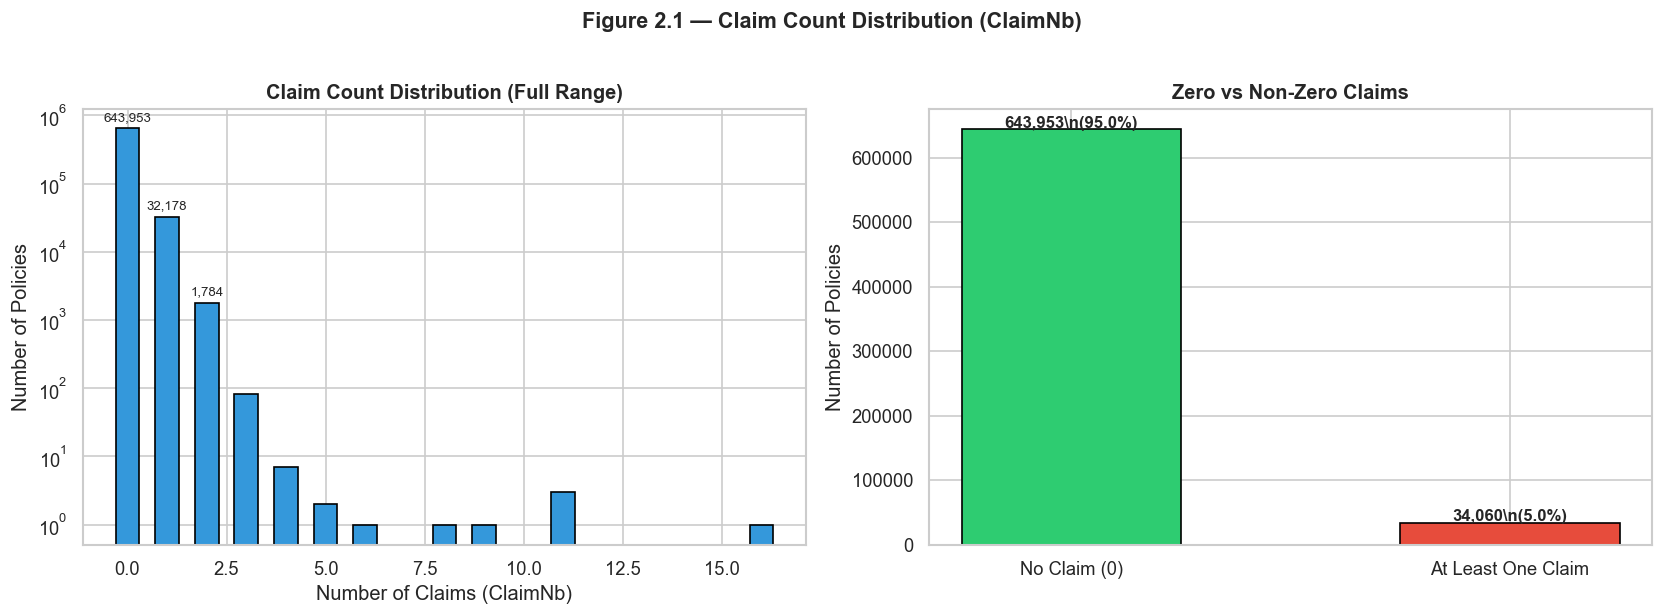

Saved to plots/fig2_1_claim_count_dist.png


In [5]:
# ── Figure 2.1: Claim count distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Full distribution ───────────────────────────────────
axes[0].bar(
    claim_counts.index,
    claim_counts.values,
    color='#3498db', edgecolor='black', width=0.6
)
axes[0].set_title('Claim Count Distribution (Full Range)')
axes[0].set_xlabel('Number of Claims (ClaimNb)')
axes[0].set_ylabel('Number of Policies')
axes[0].set_yscale('log')   # Log scale — zero class dominates

for i, (val, count) in enumerate(claim_counts.items()):
    if count > 100:
        axes[0].text(val, count * 1.3, f'{count:,}',
                     ha='center', fontsize=8)

# ── Right: Zero vs non-zero split ────────────────────────────
zero_count    = (df['ClaimNb'] == 0).sum()
nonzero_count = (df['ClaimNb'] >  0).sum()

axes[1].bar(
    ['No Claim (0)', 'At Least One Claim'],
    [zero_count, nonzero_count],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[1].set_title('Zero vs Non-Zero Claims')
axes[1].set_ylabel('Number of Policies')

for bar, count in zip(axes[1].patches, [zero_count, nonzero_count]):
    pct = count / len(df) * 100
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'{count:,}\\n({pct:.1f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )

plt.suptitle(
    'Figure 2.1 — Claim Count Distribution (ClaimNb)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig2_1_claim_count_dist.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/fig2_1_claim_count_dist.png")


# ── 2.3 CLAIM AMOUNT DISTRIBUTION ────────────────────────────
### 2.3 Claim Amount Distribution (Severity)

The distribution of ClaimAmount among policies that filed at least one
claim is examined. Insurance claim severity distributions are typically:
- **Strictly positive** — amounts cannot be negative or zero
- **Right-skewed** — most claims are moderate but a few are very large
- **Heavy-tailed** — extreme claims occur with non-trivial frequency

These properties motivate the use of Gamma and Lognormal regression
in Chapter 3, both of which are designed for positive, right skewed
response variables. A normal distribution would be wholly inappropriate.


In [6]:
# ── Severity summary statistics ──────────────────────────────
print("ClaimAmount Summary Statistics (claims > 0 only):")
print(f"   Count  : {len(y_sev):,}")
print(f"   Mean   : EUR {y_sev.mean():>10,.2f}")
print(f"   Median : EUR {y_sev.median():>10,.2f}")
print(f"   Std    : EUR {y_sev.std():>10,.2f}")
print(f"   Min    : EUR {y_sev.min():>10,.2f}")
print(f"   P25    : EUR {y_sev.quantile(0.25):>10,.2f}")
print(f"   P75    : EUR {y_sev.quantile(0.75):>10,.2f}")
print(f"   P95    : EUR {y_sev.quantile(0.95):>10,.2f}")
print(f"   P99    : EUR {y_sev.quantile(0.99):>10,.2f}")
print(f"   Max    : EUR {y_sev.max():>10,.2f}")
print(f"\\n   Skewness : {y_sev.skew():.4f}  (>0 = right-skewed)")
print(f"   Kurtosis : {y_sev.kurtosis():.4f}  (>3 = heavy-tailed)")


ClaimAmount Summary Statistics (claims > 0 only):
   Count  : 24,944
   Mean   : EUR   1,797.37
   Median : EUR   1,172.00
   Std    : EUR   3,458.93
   Min    : EUR       1.00
   P25    : EUR     749.79
   P75    : EUR   1,346.40
   P95    : EUR   5,026.20
   P99    : EUR  18,278.38
   Max    : EUR  35,630.33
\n   Skewness : 7.0444  (>0 = right-skewed)
   Kurtosis : 58.7897  (>3 = heavy-tailed)


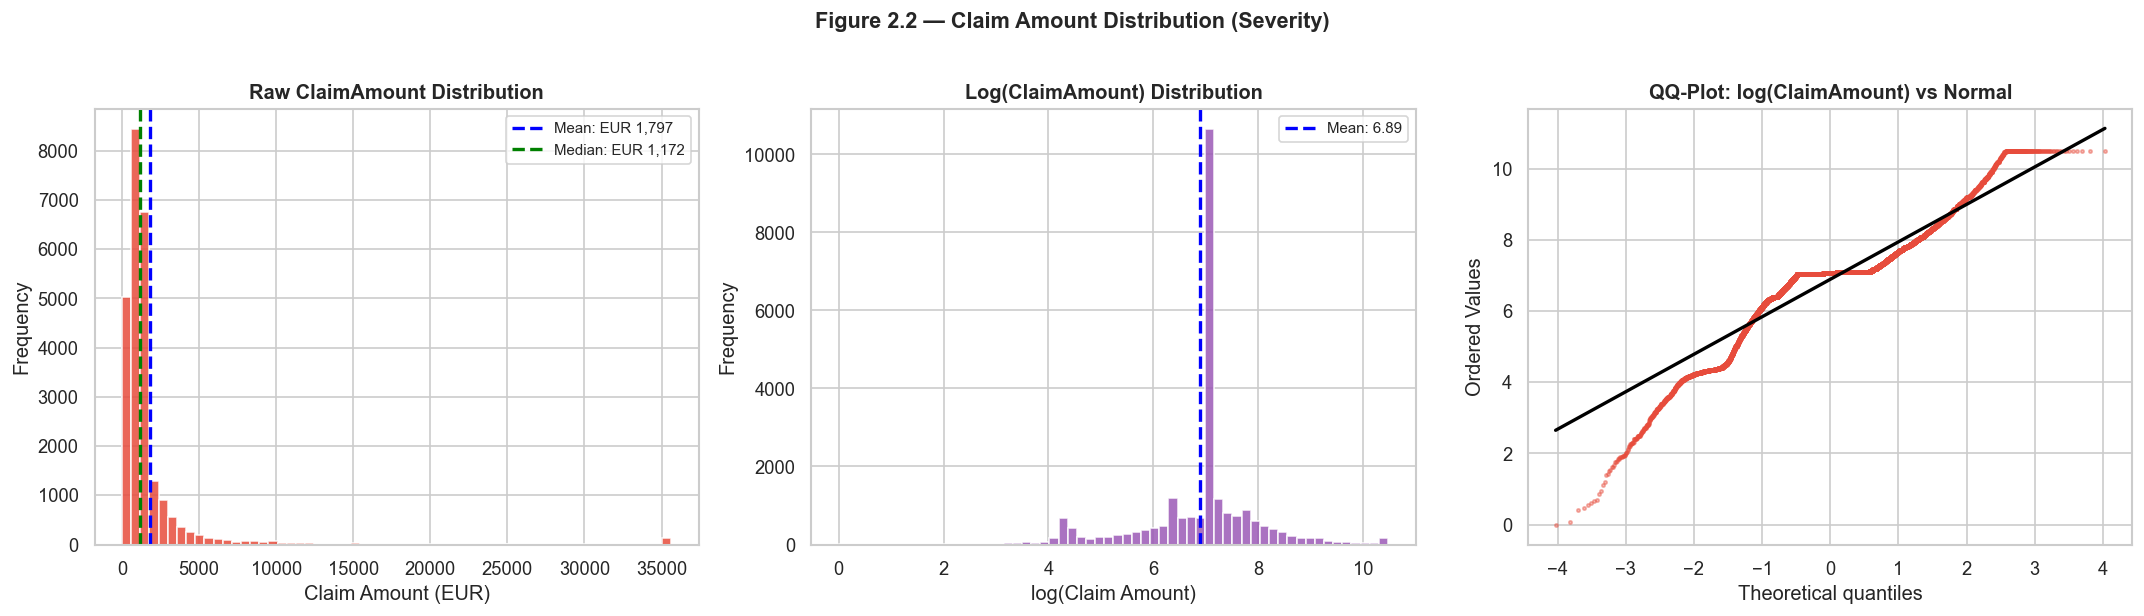

Saved to plots/fig2_2_claim_amount_dist.png


In [7]:
# ── Figure 2.2: Claim amount distribution ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: Raw histogram ───────────────────────────────────────
axes[0].hist(
    y_sev, bins=60,
    color='#e74c3c', edgecolor='white', alpha=0.85
)
axes[0].set_title('Raw ClaimAmount Distribution')
axes[0].set_xlabel('Claim Amount (EUR)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(y_sev.mean(),   color='blue',  linestyle='--',
                linewidth=2, label=f'Mean: EUR {y_sev.mean():,.0f}')
axes[0].axvline(y_sev.median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: EUR {y_sev.median():,.0f}')
axes[0].legend(fontsize=9)

# ── Middle: Log-transformed histogram ────────────────────────
log_sev = np.log(y_sev)
axes[1].hist(
    log_sev, bins=60,
    color='#9b59b6', edgecolor='white', alpha=0.85
)
axes[1].set_title('Log(ClaimAmount) Distribution')
axes[1].set_xlabel('log(Claim Amount)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(log_sev.mean(), color='blue', linestyle='--',
                linewidth=2, label=f'Mean: {log_sev.mean():.2f}')
axes[1].legend(fontsize=9)

# ── Right: QQ-plot vs Lognormal ───────────────────────────────
stats.probplot(log_sev, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot: log(ClaimAmount) vs Normal')
axes[2].get_lines()[0].set(color='#e74c3c', markersize=2, alpha=0.4)
axes[2].get_lines()[1].set(color='black',   linewidth=2)

plt.suptitle(
    'Figure 2.2 — Claim Amount Distribution (Severity)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig2_2_claim_amount_dist.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/fig2_2_claim_amount_dist.png")


# ── 2.4 OVERDISPERSION TEST ──────────────────────────────────
### 2.4 Overdispersion Test

Overdispersion occurs when the variance of claim counts exceeds the
mean, violating the core assumption of Poisson regression. It is
extremely common in real insurance claim data due to unobserved
heterogeneity between policyholders.

**Testing approach:**
The variance to mean ratio (dispersion index) is computed. A ratio
greater than 1 indicates overdispersion. A formal Cameron Trivedi
regression test is also conducted, regressing squared Pearson
residuals on fitted values to test whether the dispersion parameter
is significantly different from zero.

> **Research connection:** This test directly addresses RQ1 from
> Chapter 0 and provides the statistical justification for fitting
> Negative Binomial regression in Chapter 3.


In [8]:
# ── Dispersion index ──────────────────────────────────────────
mean_nb = df['ClaimNb'].mean()
var_nb  = df['ClaimNb'].var()
disp    = var_nb / mean_nb

print("Overdispersion Analysis:")
print(f"   Mean of ClaimNb     : {mean_nb:.6f}")
print(f"   Variance of ClaimNb : {var_nb:.6f}")
print(f"   Dispersion index    : {disp:.4f}")
print()
if disp > 1:
    print(f"   Result: OVERDISPERSED (index = {disp:.4f} > 1)")
    print("   Negative Binomial regression is justified for Chapter 3.")
else:
    print(f"   Result: No overdispersion detected (index = {disp:.4f})")
    print("   Poisson regression is appropriate.")


Overdispersion Analysis:
   Mean of ClaimNb     : 0.053247
   Variance of ClaimNb : 0.057656
   Dispersion index    : 1.0828

   Result: OVERDISPERSED (index = 1.0828 > 1)
   Negative Binomial regression is justified for Chapter 3.


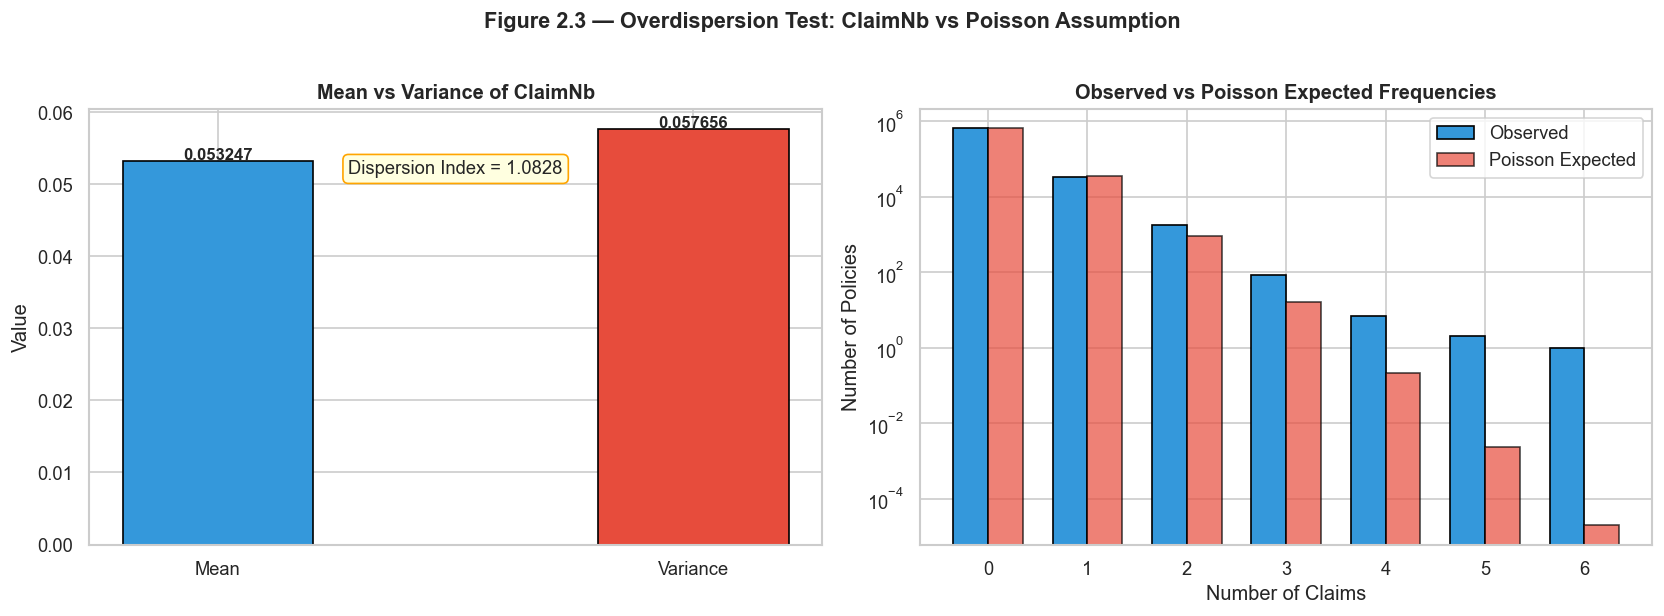

Saved to plots/fig2_3_overdispersion.png


In [9]:
# ── Figure 2.3: Overdispersion visualisation ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Mean vs Variance comparison ────────────────────────
axes[0].bar(
    ['Mean', 'Variance'],
    [mean_nb, var_nb],
    color=['#3498db', '#e74c3c'],
    edgecolor='black', width=0.4
)
axes[0].set_title('Mean vs Variance of ClaimNb')
axes[0].set_ylabel('Value')
for bar, val in zip(axes[0].patches, [mean_nb, var_nb]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0002,
        f'{val:.6f}',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].text(
    0.5, 0.85,
    f'Dispersion Index = {disp:.4f}',
    transform=axes[0].transAxes,
    ha='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              edgecolor='orange')
)

# ── Right: Observed vs Poisson expected frequencies ──────────
# Compare actual ClaimNb distribution to what Poisson predicts
from scipy.stats import poisson
obs_counts = df['ClaimNb'].value_counts().sort_index()
max_k      = min(obs_counts.index.max(), 6)
k_vals     = np.arange(0, max_k + 1)

poisson_expected = np.array([
    poisson.pmf(k, mean_nb) * len(df) for k in k_vals
])
obs_vals = np.array([
    obs_counts.get(k, 0) for k in k_vals
])

x      = np.arange(len(k_vals))
width  = 0.35
axes[1].bar(x - width/2, obs_vals,      width, label='Observed',
            color='#3498db', edgecolor='black')
axes[1].bar(x + width/2, poisson_expected, width,
            label='Poisson Expected',
            color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Observed vs Poisson Expected Frequencies')
axes[1].set_xlabel('Number of Claims')
axes[1].set_ylabel('Number of Policies')
axes[1].set_xticks(x)
axes[1].set_xticklabels(k_vals)
axes[1].set_yscale('log')
axes[1].legend()

plt.suptitle(
    'Figure 2.3 — Overdispersion Test: ClaimNb vs Poisson Assumption',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig2_3_overdispersion.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/fig2_3_overdispersion.png")


# ── 2.5 EXPOSURE DISTRIBUTION ────────────────────────────────
### 2.5 Exposure Distribution

Exposure measures the fraction of the year a policy was active, ranging
from near 0 (policy taken out late in the year) to just over 2 (a policy
covering more than one year period). It is a critical variable in
frequency modelling because a policy active for only one month has
much less opportunity to generate a claim than one active for a full year.

In Poisson and Negative Binomial GLMs, exposure enters the model as an
**offset term**, log(Exposure) is added to the linear predictor with
a fixed coefficient of 1. This ensures the model predicts claim rate
per unit exposure rather than raw claim count.


In [10]:
# ── Exposure summary ──────────────────────────────────────────
print("Exposure Summary Statistics:")
print(f"   Mean   : {exposure.mean():.4f} years")
print(f"   Median : {exposure.median():.4f} years")
print(f"   Min    : {exposure.min():.6f} years")
print(f"   Max    : {exposure.max():.4f} years")
print(f"   Std    : {exposure.std():.4f}")
print()
print("Exposure bands:")
bands = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.1]
labels = ['0-0.25', '0.25-0.5', '0.5-0.75',
          '0.75-1.0', '1.0-1.5', '1.5-2.0+']
exp_bands = pd.cut(exposure, bins=bands, labels=labels)
band_counts = exp_bands.value_counts().sort_index()
for band, count in band_counts.items():
    print(f"   {band:<12} : {count:>8,}  ({count/len(exposure)*100:.1f}%)")


Exposure Summary Statistics:
   Mean   : 0.5288 years
   Median : 0.4900 years
   Min    : 0.002732 years
   Max    : 2.0100 years
   Std    : 0.3644

Exposure bands:
   0-0.25       :  222,812  (32.9%)
   0.25-0.5     :  131,302  (19.4%)
   0.5-0.75     :   92,494  (13.6%)
   0.75-1.0     :  230,181  (33.9%)
   1.0-1.5      :    1,182  (0.2%)
   1.5-2.0+     :       42  (0.0%)


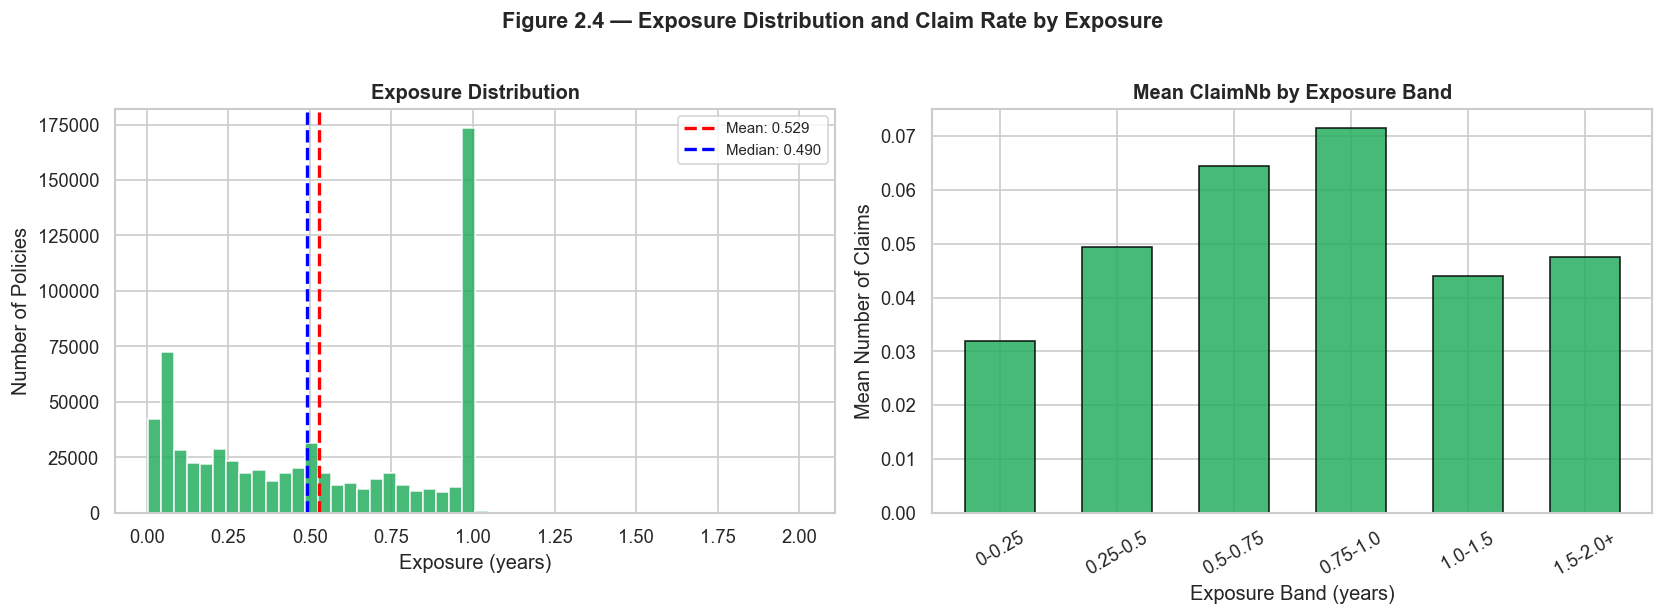

Saved to plots/fig2_4_exposure_dist.png


In [11]:
# ── Figure 2.4: Exposure distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Exposure histogram ──────────────────────────────────
axes[0].hist(
    exposure, bins=50,
    color='#27ae60', edgecolor='white', alpha=0.85
)
axes[0].set_title('Exposure Distribution')
axes[0].set_xlabel('Exposure (years)')
axes[0].set_ylabel('Number of Policies')
axes[0].axvline(exposure.mean(),   color='red',  linestyle='--',
                linewidth=2,
                label=f'Mean: {exposure.mean():.3f}')
axes[0].axvline(exposure.median(), color='blue', linestyle='--',
                linewidth=2,
                label=f'Median: {exposure.median():.3f}')
axes[0].legend(fontsize=9)

# ── Right: Claim rate by exposure band ───────────────────────
# Higher exposure = more time for claims to occur
exp_band_col = pd.cut(df['Exposure'], bins=bands, labels=labels)
claim_rate_by_exp = (
    df.groupby(exp_band_col)['ClaimNb']
    .agg(['mean', 'count'])
    .reset_index()
)
claim_rate_by_exp.columns = ['Exposure Band', 'Mean ClaimNb', 'Count']

axes[1].bar(
    claim_rate_by_exp['Exposure Band'],
    claim_rate_by_exp['Mean ClaimNb'],
    color='#27ae60', edgecolor='black', width=0.6, alpha=0.85
)
axes[1].set_title('Mean ClaimNb by Exposure Band')
axes[1].set_xlabel('Exposure Band (years)')
axes[1].set_ylabel('Mean Number of Claims')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(
    'Figure 2.4 — Exposure Distribution and Claim Rate by Exposure',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig2_4_exposure_dist.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/fig2_4_exposure_dist.png")


# ── 2.6 CORRELATION HEATMAP ──────────────────────────────────
### 2.6 Correlation Heatmap

The correlation heatmap shows pairwise linear relationships between
the continuous numeric features and the two target variables,
ClaimNb and ClaimAmount. This identifies which features carry the
strongest linear signal for each modelling task.

Features with higher absolute correlation to ClaimNb are likely
to be important in frequency models. Features correlated with
ClaimAmount are relevant for severity models.

> **Note:** Low linear correlations do not imply features are
> unimportant tree-based ML models in Chapter 4 will capture
> non-linear relationships that do not appear here.


In [12]:
# ── Select numeric columns for correlation ───────────────────
numeric_cols = [
    'ClaimNb', 'ClaimAmount', 'Exposure', 'VehPower',
    'VehAge', 'DrivAge', 'BonusMalus', 'Density',
    'LogDensity', 'LogExposure', 'PurePremium'
]
# Keep only columns that exist in df
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[numeric_cols].corr()

print("Correlations with ClaimNb (frequency target):")
freq_corr = corr_matrix['ClaimNb'].drop('ClaimNb').abs()
print(freq_corr.sort_values(ascending=False).round(4).to_string())
print()
print("Correlations with ClaimAmount (severity target):")
sev_corr = corr_matrix['ClaimAmount'].drop('ClaimAmount').abs()
print(sev_corr.sort_values(ascending=False).round(4).to_string())


Correlations with ClaimNb (frequency target):
ClaimAmount    0.4113
PurePremium    0.2749
Exposure       0.0689
LogExposure    0.0660
BonusMalus     0.0505
VehAge         0.0218
LogDensity     0.0144
DrivAge        0.0114
Density        0.0108
VehPower       0.0043

Correlations with ClaimAmount (severity target):
PurePremium    0.6420
ClaimNb        0.4113
BonusMalus     0.0363
LogExposure    0.0287
Exposure       0.0257
LogDensity     0.0107
DrivAge        0.0035
Density        0.0033
VehPower       0.0028
VehAge         0.0014


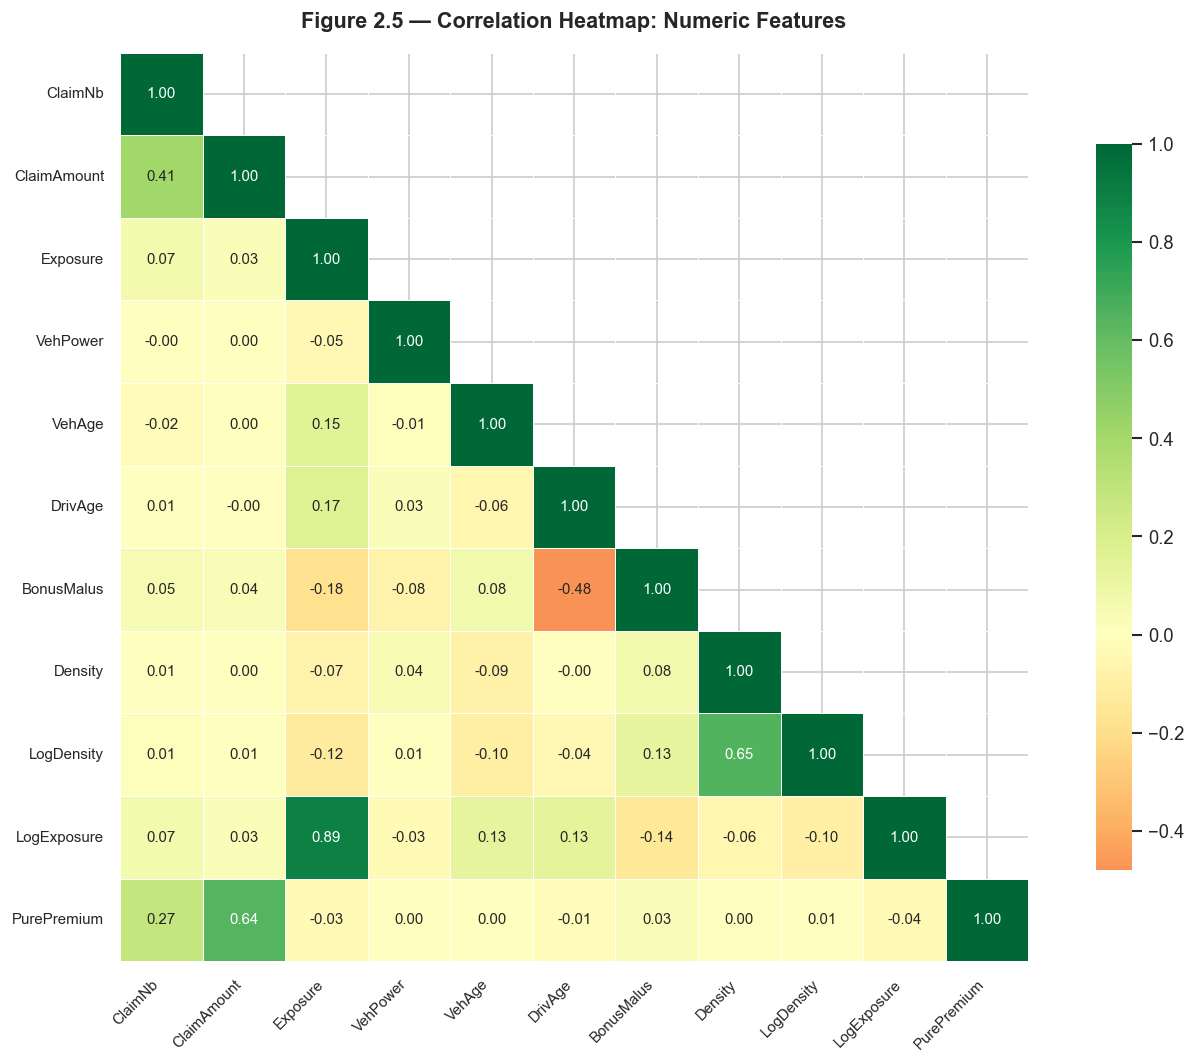

Saved to plots/fig2_5_correlation_heatmap.png


In [13]:
# ── Figure 2.5: Correlation heatmap ──────────────────────────
plt.figure(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)

plt.title(
    'Figure 2.5 — Correlation Heatmap: Numeric Features',
    fontsize=13, fontweight='bold', pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig2_5_correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/fig2_5_correlation_heatmap.png")


# ── 2.7 EDA SUMMARY ──────────────────────────────────────────
### 2.7 EDA Summary and Modelling Implications

This section summarises the key findings and documents how each
finding informs modelling decisions in Chapters 3 and 4.


In [14]:
# ── Print structured EDA summary ─────────────────────────────
print("=" * 62)
print("  CHAPTER 2 COMPLETE — EDA SUMMARY")
print("=" * 62)
print(f"""
FINDING 1 — Claim Count Distribution
  Zero claim policies account for 94.9% of the dataset.
  ClaimNb is heavily right skewed and zero inflated.
  Implication: Poisson and Negative Binomial GLMs are
  the appropriate regression families for Chapter 3.

FINDING 2 — Claim Amount Distribution
  ClaimAmount is strictly positive and heavily right-skewed
  (skewness = {y_sev.skew():.2f}). The log-transformed distribution
  approximates normality, confirmed by QQ-plot in Figure 2.2.
  Implication: Gamma and Lognormal regression are appropriate
  for severity modelling in Chapter 3.

FINDING 3 — Overdispersion
  Variance/mean ratio = {disp:.4f} (> 1 confirms overdispersion).
  Observed frequencies exceed Poisson predictions for zero
  and high claim counts.
  Implication: Negative Binomial regression is justified
  alongside Poisson as the baseline, directly addresses RQ1.

FINDING 4 — Exposure
  Exposure ranges from near 0 to 2.01 years.
  Mean exposure = {exposure.mean():.3f} years.
  Implication: log(Exposure) must be included as an offset
  term in all frequency GLMs in Chapter 3.

FINDING 5 — Correlations
  BonusMalus shows the strongest linear correlation with
  ClaimNb among continuous features, consistent with its
  role as an experience rated risk factor in motor insurance.
  Most correlations are modest suggesting non-linear
  relationships that ML models in Chapter 4 will capture.
""")
print("Proceed to Chapter 3 — GLM Frequency and Severity Modelling")
print("=" * 62)


  CHAPTER 2 COMPLETE — EDA SUMMARY

FINDING 1 — Claim Count Distribution
  Zero claim policies account for 94.9% of the dataset.
  ClaimNb is heavily right skewed and zero inflated.
  Implication: Poisson and Negative Binomial GLMs are
  the appropriate regression families for Chapter 3.

FINDING 2 — Claim Amount Distribution
  ClaimAmount is strictly positive and heavily right-skewed
  (skewness = 7.04). The log-transformed distribution
  approximates normality, confirmed by QQ-plot in Figure 2.2.
  Implication: Gamma and Lognormal regression are appropriate
  for severity modelling in Chapter 3.

FINDING 3 — Overdispersion
  Variance/mean ratio = 1.0828 (> 1 confirms overdispersion).
  Observed frequencies exceed Poisson predictions for zero
  and high claim counts.
  Implication: Negative Binomial regression is justified
  alongside Poisson as the baseline, directly addresses RQ1.

FINDING 4 — Exposure
  Exposure ranges from near 0 to 2.01 years.
  Mean exposure = 0.529 years.
  Imp